In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 1. Load the dataset

In [66]:
# import the libs we need
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
import tensorflow as tf
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv("/kaggle/input/datasets/amjadzhour/car-price-prediction/Car_Price_Prediction.csv")
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1000.0,2010.68800,6.288577,2000.000000,2005.00000,2011.000000,2016.000000,2021.000000
Engine Size,1000.0,2.79830,1.024137,1.000000,1.90000,2.800000,3.700000,4.500000
Mileage,1000.0,97192.48700,59447.315760,56.000000,44768.75000,94411.500000,148977.750000,199867.000000
Price,1000.0,25136.61553,5181.401368,6704.953524,21587.87837,25189.325247,28806.368974,41780.504635


In [9]:
df.nunique()

Make               5
Model              5
Year              22
Engine Size       36
Mileage          997
Fuel Type          3
Transmission       2
Price           1000
dtype: int64

In [38]:
plt.figure(figsize = (7,5))
fig = px.bar(data_frame = df,x = "Make",y = "Price",color = "Model")
fig.show()

<Figure size 700x500 with 0 Axes>

In [21]:
df["Year"].value_counts(normalize = True)

Year
2014    0.058
2008    0.057
2016    0.056
2015    0.055
2000    0.054
2009    0.052
2003    0.050
2010    0.049
2012    0.048
2021    0.047
2018    0.044
2017    0.044
2013    0.043
2019    0.042
2011    0.040
2020    0.040
2002    0.040
2001    0.039
2004    0.038
2006    0.036
2005    0.036
2007    0.032
Name: proportion, dtype: float64

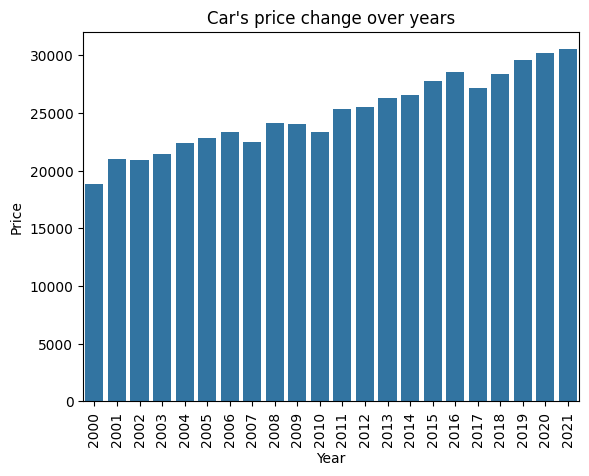

In [28]:
years_price_analysis = df.groupby("Year")["Price"].agg("mean").reset_index()
plt.figure()
sns.barplot(data = years_price_analysis,x = "Year",y = "Price")
plt.xticks(rotation = 90)
plt.title("Car's price change over years",fontsize = 12)
plt.show()

In [34]:
df["Fuel Type"].value_counts()

Fuel Type
Diesel      344
Petrol      331
Electric    325
Name: count, dtype: int64

In [37]:
fuel_types_price_analysis = df.groupby(["Fuel Type","Year"])["Price"].agg("mean").reset_index()
fig = px.bar(data_frame = fuel_types_price_analysis,x = "Year",y = "Price",color = "Fuel Type",title = "The Fuel Type and Price Analysis")
fig.show()

* From 2000 to 2021, the fuel type affects the price of a car.

In [39]:
# Transmission and Price Analysis
transmission_price_analysis = df.groupby("Transmission")["Price"].agg("mean").reset_index()
transmission_price_analysis


,Transmission,Price
0,Automatic,25272.048139
1,Manual,25007.013680


In [41]:
fig  = px.bar(data_frame = transmission_price_analysis,x = "Transmission",y = "Price",title = "Transmission and Price Analysis")
fig.show()

* There is a little difference in price

In [50]:
mileage_analysis = df.groupby(["Make","Year"])["Mileage"].agg("sum").reset_index()
mileage_analysis

,Make,Year,Mileage
0,Audi,2000,1130132
1,Audi,2001,1103990
2,Audi,2002,984230
3,Audi,2003,894631
4,Audi,2004,1068692
...,...,...,...
104,Toyota,2017,846741
105,Toyota,2018,739690
106,Toyota,2019,386621
107,Toyota,2020,389867


In [51]:
# Mileage and Make, Model Analysis
fig = px.line(data_frame = mileage_analysis,x = "Year",y = "Mileage",color = "Make",title = "Mileage and Make Analysis")
fig.show()

# 2. Preprocessing and Modeling

In [53]:
df.dtypes

Make             object
Model            object
Year              int64
Engine Size     float64
Mileage           int64
Fuel Type        object
Transmission     object
Price           float64
dtype: object

In [59]:
mct = make_column_transformer((MinMaxScaler(),["Year","Engine Size","Mileage"]),
                           (OneHotEncoder(),["Make","Model","Fuel Type","Transmission"]))

In [60]:
X = df.drop(columns = "Price",axis = 1)
y = df["Price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((800, 7), (200, 7), (800,), (200,))

In [62]:
X_train_scaled = mct.fit_transform(X_train)
X_test_scaled = mct.transform(X_test)
X_train_scaled

array([[0.95238095, 0.31428571, 0.50238388, ..., 1.        , 0.        ,
        1.        ],
       [0.80952381, 0.74285714, 0.12293886, ..., 0.        , 1.        ,
        0.        ],
       [0.0952381 , 0.57142857, 0.91717344, ..., 1.        , 1.        ,
        0.        ],
       ...,
       [0.57142857, 0.88571429, 0.91224526, ..., 0.        , 0.        ,
        1.        ],
       [0.14285714, 0.65714286, 0.38047778, ..., 1.        , 0.        ,
        1.        ],
       [0.66666667, 1.        , 0.61330559, ..., 0.        , 0.        ,
        1.        ]])

In [69]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(200,activation = "relu"),
    tf.keras.layers.Dense(100,activation = "relu"),
    tf.keras.layers.Dense(50,activation = "relu"),
    tf.keras.layers.Dense(10,activation = "relu"),
    tf.keras.layers.Dense(1)
])

model.compile(loss = tf.keras.losses.mae,
             optimizer = tf.keras.optimizers.Adam(learning_rate = 0.009),
             metrics = ["mae"])

history = model.fit(X_train_scaled,y_train,epochs = 100,validation_split=0.2)

model.evaluate(X_test_scaled,y_test)

model.summary()

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 24525.9160 - mae: 24525.9160 - val_loss: 22009.6758 - val_mae: 22009.6758
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10047.7178 - mae: 10047.7178 - val_loss: 5463.5537 - val_mae: 5463.5537
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4415.2734 - mae: 4415.2734 - val_loss: 4213.4453 - val_mae: 4213.4453
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3708.6809 - mae: 3708.6809 - val_loss: 3631.7212 - val_mae: 3631.7212
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2844.9434 - mae: 2844.9434 - val_loss: 2707.0950 - val_mae: 2707.0950
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2211.2317 - mae: 2211.2317 - val_loss: 2133.2693 - val_mae: 2133.2693
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1868.9297 - mae: 1868.9297 - val_loss: 1794.2220 - val_mae: 1794.2220
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1782.8386 - mae: 1782.8386 - va

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (32, 200)              │         3,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (32, 100)              │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (32, 50)               │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (32, 10)               │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (32, 1)                │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,415 (345.38 KB)

 Trainable params: 29,471 (115.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,944 (230.25 KB)

<Axes: title={'center': 'Model Performance'}>

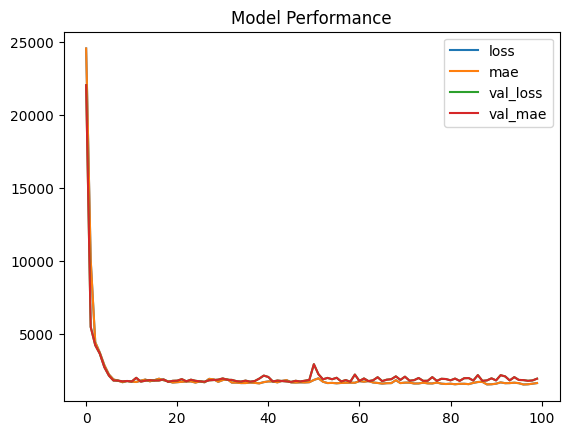

In [70]:
pd.DataFrame(history.history).plot(title = "Model Performance")

In [71]:
y_pred = model.predict(X_test_scaled)
y_pred

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[27332.844],
       [19552.574],
       [20035.219],
       [31351.863],
       [24068.662],
       [25375.377],
       [20545.822],
       [25060.324],
       [25591.484],
       [30478.049],
       [28553.51 ],
       [30186.566],
       [21957.105],
       [20949.223],
       [33846.492],
       [29497.295],
       [26491.133],
       [23324.201],
       [27978.02 ],
       [36231.652],
       [23350.465],
       [23423.625],
       [23261.824],
       [17496.152],
       [25025.738],
       [26730.59 ],
       [22014.377],
       [18243.027],
       [23921.281],
       [29275.422],
       [23851.844],
       [22118.947],
       [28555.385],
       [20970.148],
       [30952.965],
       [21268.488],
       [23498.648],
       [18318.61 ],
       [29663.45 ],
       [25124.871],
       [30692.416],
       [30131.816],
       [25702.936],
       [22420.523],
       [15781.361],
       [24672.906],
       [22342.273],
       [27299.78 ],
       [19776.387],
       [22898.553],


In [72]:
r2_ = r2_score(y_test,y_pred)
r2_

0.756201959032692

## The End ##